
# EqVIO Equivariant Filter Example

## An Equivariant Filter for Visual-Inertial Odometry

This notebook demonstrates the Equivariant Filter (EqF) for state estimation in a visual-inertial odometry context, based on the paper:

> **"EqVIO: An Equivariant Filter for Visual Inertial Odometry"** by van Goor et al.

In this tutorial, we will utilize a subset of the [EuRoC MAV](https://projects.asl.ethz.ch/datasets/euroc-mav/) dataset, which is a series of stereo images and synchronized IMU measurements collected on micro-aerial-vehicles (MAVs). We will:

- load a processed 60 second EqVIO replay log,
- run the `EqVIOFilter` through the IMU and vision measurements,
- compare the estimated **translation trajectory** against EuRoC ground truth in 3D, and
- compare the estimated **velocity** against EuRoC ground truth over time.

This demo uses the `gtsam_unstable.EqVIOFilter` class which provides a clean interface for predict/update operations.

**Note**: We have hidden verbose loading/plotting functions under cell dropdowns. Feel free to expand to take a closer look.

GTSAM Copyright 2010-2026, Georgia Tech Research Corporation,
Atlanta, Georgia 30332-0415
All Rights Reserved
Authors: Frank Dellaert, et al. (see THANKS for the full author list)

See LICENSE for the license information

Try it out in Colab!

<a href="https://colab.research.google.com/github/borglab/AwesomeEqf/blob/master/notebooks/02_eqvio_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
try:
    import google.colab
    %pip install --quiet gtsam-develop
except ImportError:
    pass


## Setup and Imports

We will use:

- `gtsam_unstable.eqvio` for the filter
- `matplotlib` for plotting
- the processed replay CSV for IMU and feature measurements
- the original EuRoC ground-truth CSV for clean pose and velocity references

The data files are located in this AwesomeEqF repository under the `data` folder.


In [2]:

from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
import csv
import math
from typing import Dict, List, Optional

import matplotlib.pyplot as plt
import numpy as np

import gtsam
import gtsam_unstable



## Grab the Input Files

We preprocess the EuRoC MAV dataset such that the first 60 seconds of Vicon Room 1 are available to us in `eqvio_processed_60s.csv`. This preprocessing runs [GIFT](https://github.com/pvangoor/GIFT) (a library developed by [van Goor](https://pvangoor.github.io/) to perform invariant feature tracking) as well so that we can abstract away the minutae and focus on the filter logic. 

We also obtain the ground truth data from the dataset to compare against the filter output.

In [9]:

REPLAY_CSV = Path('../data/eqvio_processed_60s.csv')
GROUNDTRUTH_CSV = Path('../data/eqvio_ground_truth.csv')

REPLAY_CSV, GROUNDTRUTH_CSV


(PosixPath('../data/eqvio_processed_60s.csv'),
 PosixPath('../data/eqvio_ground_truth.csv'))


## Data Structures

The processed replay log makes use of three kinds of rows:

- `meta` rows for configuration and calibration,
- `imu` rows for inertial samples, and
- `vision_feature` rows for tracked feature bearings.

We load those into simple Python dataclasses so the replay logic stays easy to read.


In [4]:

@dataclass
class ReplayEvent:
    kind: str
    seq: int
    t_abs: float
    t_rel: float = 0.0
    frame_idx: int = -1
    imu: Optional[gtsam_unstable.eqvio.IMUInput] = None
    vision: Dict[int, np.ndarray] = field(default_factory=dict)


@dataclass
class ReplayLog:
    metadata: Dict[str, str]
    events: List[ReplayEvent]


@dataclass
class GroundTruthTrajectory:
    t_abs: np.ndarray
    position_world: np.ndarray
    quaternion_wxyz: np.ndarray
    velocity_world: np.ndarray


@dataclass
class BufferedImuPropagation:
    imu_inputs: List[gtsam_unstable.eqvio.IMUInput] = field(default_factory=list)
    dts: List[float] = field(default_factory=list)
    propagated_time: float = 0.0
    trim_count: int = 0


@dataclass
class TimestampedImu:
    t_abs: float
    imu: gtsam_unstable.eqvio.IMUInput


@dataclass
class RigidAlignment:
    rotation: np.ndarray
    translation: np.ndarray


@dataclass
class ReplayResults:
    t_abs: np.ndarray
    t_rel: np.ndarray
    est_position: np.ndarray
    est_velocity: np.ndarray
    gt_position_world: np.ndarray
    gt_position_aligned: np.ndarray
    gt_velocity_body: np.ndarray
    alignment: RigidAlignment
    measurement_noise_variance: float
    final_landmark_count: int


def _parse_float(text: str, fallback: float = 0.0) -> float:
    if text is None or text == '':
        return fallback
    return float(text)


def _parse_int(text: str, fallback: int = 0) -> int:
    if text is None or text == '':
        return fallback
    return int(text)


def _metadata_finite_float(metadata: Dict[str, str], key: str, fallback: float) -> float:
    if key not in metadata or metadata[key] == '':
        return fallback
    try:
        value = float(metadata[key])
        return value if math.isfinite(value) else fallback
    except ValueError:
        return fallback


def _required_columns() -> List[str]:
    return [
        'row_type',
        't_abs',
        't_rel',
        'seq',
        'frame_idx',
        'landmark_id',
        'gx',
        'gy',
        'gz',
        'ax',
        'ay',
        'az',
        'bgx',
        'bgy',
        'bgz',
        'bax',
        'bay',
        'baz',
        'u_norm',
        'v_norm',
        'key',
        'value',
    ]


def read_replay_csv(csv_path: Path) -> ReplayLog:
    metadata: Dict[str, str] = {}
    events: List[ReplayEvent] = []
    seq_to_vision_event: Dict[int, int] = {}

    with csv_path.open(newline='', encoding='utf-8') as handle:
        reader = csv.DictReader(handle)
        if reader.fieldnames is None:
            raise ValueError(f'Empty replay CSV: {csv_path}')

        for key in _required_columns():
            if key not in reader.fieldnames:
                raise ValueError(f'Missing required replay column: {key}')

        for row in reader:
            row_type = (row.get('row_type') or '').strip()
            if not row_type:
                continue

            if row_type == 'meta':
                key = (row.get('key') or '').strip()
                if key:
                    metadata[key] = (row.get('value') or '').strip()
                continue

            seq = _parse_int(row.get('seq'), 0)
            t_abs = _parse_float(row.get('t_abs'), 0.0)
            t_rel = _parse_float(row.get('t_rel'), 0.0)

            if row_type == 'imu':
                imu = gtsam_unstable.eqvio.IMUInput()
                imu.stamp = t_abs
                imu.gyr = np.array([
                    _parse_float(row.get('gx')),
                    _parse_float(row.get('gy')),
                    _parse_float(row.get('gz')),
                ])
                imu.acc = np.array([
                    _parse_float(row.get('ax')),
                    _parse_float(row.get('ay')),
                    _parse_float(row.get('az')),
                ])
                imu.gyrBiasVel = np.array([
                    _parse_float(row.get('bgx')),
                    _parse_float(row.get('bgy')),
                    _parse_float(row.get('bgz')),
                ])
                imu.accBiasVel = np.array([
                    _parse_float(row.get('bax')),
                    _parse_float(row.get('bay')),
                    _parse_float(row.get('baz')),
                ])
                events.append(ReplayEvent(kind='imu', seq=seq, t_abs=t_abs, t_rel=t_rel, imu=imu))
                continue

            if row_type == 'vision_feature':
                frame_idx = _parse_int(row.get('frame_idx'), -1)
                landmark_id = _parse_int(row.get('landmark_id'), 0)
                u_norm = _parse_float(row.get('u_norm'), 0.0)
                v_norm = _parse_float(row.get('v_norm'), 0.0)

                if seq not in seq_to_vision_event:
                    event = ReplayEvent(
                        kind='vision',
                        seq=seq,
                        t_abs=t_abs,
                        t_rel=t_rel,
                        frame_idx=frame_idx,
                        vision={landmark_id: np.array([u_norm, v_norm])},
                    )
                    seq_to_vision_event[seq] = len(events)
                    events.append(event)
                else:
                    event = events[seq_to_vision_event[seq]]
                    event.vision[landmark_id] = np.array([u_norm, v_norm])
                continue

            raise ValueError(f'Unknown row_type: {row_type}')

    events.sort(key=lambda event: event.seq)
    return ReplayLog(metadata=metadata, events=events)


def read_groundtruth_csv(csv_path: Path) -> GroundTruthTrajectory:
    t_abs: List[float] = []
    position_world: List[np.ndarray] = []
    quaternion_wxyz: List[np.ndarray] = []
    velocity_world: List[np.ndarray] = []

    with csv_path.open(newline='', encoding='utf-8') as handle:
        reader = csv.reader(handle)
        header = next(reader, None)
        if header is None:
            raise ValueError(f'Empty ground-truth CSV: {csv_path}')

        for row in reader:
            t_abs.append(float(row[0]) * 1e-9)
            position_world.append(np.array([float(row[1]), float(row[2]), float(row[3])]))
            quaternion_wxyz.append(np.array([float(row[4]), float(row[5]), float(row[6]), float(row[7])]))
            velocity_world.append(np.array([float(row[8]), float(row[9]), float(row[10])]))

    return GroundTruthTrajectory(
        t_abs=np.asarray(t_abs),
        position_world=np.vstack(position_world),
        quaternion_wxyz=np.vstack(quaternion_wxyz),
        velocity_world=np.vstack(velocity_world),
    )



## Load the Replay Log and EuRoC Ground Truth

The replay log is the compact event stream that drives the filter. The EuRoC ground-truth file gives us the reference position, orientation, and world-frame velocity trajectory we will use for evaluation.


In [10]:

log = read_replay_csv(REPLAY_CSV)
groundtruth = read_groundtruth_csv(GROUNDTRUTH_CSV)

imu_events = sum(event.kind == 'imu' for event in log.events)
vision_events = sum(event.kind == 'vision' for event in log.events)
vision_features = sum(len(event.vision) for event in log.events if event.kind == 'vision')

print(f'Replay events: {len(log.events)}')
print(f'IMU events: {imu_events}')
print(f'Vision frames: {vision_events}')
print(f'Vision features: {vision_features}')
print(f"Replay duration (metadata): {log.metadata.get('duration_sec', 'unknown')} s")
print(f'Ground-truth samples: {len(groundtruth.t_abs)}')

Replay events: 13202
IMU events: 12001
Vision frames: 1201
Vision features: 29531
Replay duration (metadata): 60 s
Ground-truth samples: 28712



## Replay Helpers

The next cell packages the same replay logic as the raw script, but adds two pieces that make the tutorial more useful:

- sampling the estimated state after each visual update, and
- aligning/interpolating ground truth so we can plot meaningful comparisons.

A key detail is that **translation** and **velocity** need slightly different treatment:

- For the 3D trajectory plot, we align ground truth to the filter's arbitrary global frame with a rigid transform.
- For the velocity plot, we compare against **body-frame ground-truth velocity**, because that matches the convention exposed by `EqVIOFilter.velocity()`.


In [11]:

def _camera_offset_from_metadata(metadata: Dict[str, str]) -> Optional[gtsam.Pose3]:
    keys = ['T_ci_tx', 'T_ci_ty', 'T_ci_tz', 'T_ci_qw', 'T_ci_qx', 'T_ci_qy', 'T_ci_qz']
    if any(k not in metadata or metadata[k] == '' for k in keys):
        return None

    tx = float(metadata['T_ci_tx'])
    ty = float(metadata['T_ci_ty'])
    tz = float(metadata['T_ci_tz'])
    qw = float(metadata['T_ci_qw'])
    qx = float(metadata['T_ci_qx'])
    qy = float(metadata['T_ci_qy'])
    qz = float(metadata['T_ci_qz'])

    norm = math.sqrt(qw * qw + qx * qx + qy * qy + qz * qz)
    if norm <= 1e-12:
        return None
    qw /= norm
    qx /= norm
    qy /= norm
    qz /= norm

    return gtsam.Pose3(gtsam.Rot3.Quaternion(qw, qx, qy, qz), np.array([tx, ty, tz]))


def _initial_covariance_from_metadata(metadata: Dict[str, str]) -> np.ndarray:
    sigma0 = np.eye(21)

    def set_initial_variance_block(idx: int, key: str, fallback: float) -> None:
        sigma0[idx : idx + 3, idx : idx + 3] *= _metadata_finite_float(metadata, key, fallback)

    set_initial_variance_block(0, 'eqf.initial_var_bias_omega', 0.1)
    set_initial_variance_block(3, 'eqf.initial_var_bias_accel', 0.1)
    set_initial_variance_block(6, 'eqf.initial_var_attitude', 1e-4)
    set_initial_variance_block(9, 'eqf.initial_var_position', 1e-4)
    set_initial_variance_block(12, 'eqf.initial_var_velocity', 1e-2)
    set_initial_variance_block(15, 'eqf.initial_var_cam_attitude', 1e-5)
    set_initial_variance_block(18, 'eqf.initial_var_cam_position', 1e-4)
    return sigma0


def _params_from_metadata(metadata: Dict[str, str]) -> gtsam_unstable.eqvio.EqVIOFilterParams:
    params = gtsam_unstable.eqvio.EqVIOFilterParams()
    params.initialPointDepth = _metadata_finite_float(metadata, 'eqf.initial_point_depth', 10.0)
    params.initialPointVariance = _metadata_finite_float(metadata, 'eqf.initial_point_variance', 1.0)

    outlier_threshold_abs = _metadata_finite_float(metadata, 'eqf.outlier_threshold_abs', 1e8)
    outlier_threshold_abs = _metadata_finite_float(
        metadata, 'eqf.outlier_threshold_abs_norm', outlier_threshold_abs
    )
    params.outlierThresholdAbs = outlier_threshold_abs
    params.featureRetention = _metadata_finite_float(metadata, 'eqf.feature_retention', 0.3)
    params.biasOmegaProcessVariance = _metadata_finite_float(
        metadata, 'eqf.process_var_bias_omega', 0.001
    )
    params.biasAccelProcessVariance = _metadata_finite_float(
        metadata, 'eqf.process_var_bias_accel', 0.001
    )
    params.attitudeProcessVariance = _metadata_finite_float(
        metadata, 'eqf.process_var_attitude', 0.001
    )
    params.positionProcessVariance = _metadata_finite_float(
        metadata, 'eqf.process_var_position', 0.001
    )
    params.velocityProcessVariance = _metadata_finite_float(
        metadata, 'eqf.process_var_velocity', 0.001
    )
    params.cameraAttitudeProcessVariance = _metadata_finite_float(
        metadata, 'eqf.process_var_cam_attitude', 0.001
    )
    params.cameraPositionProcessVariance = _metadata_finite_float(
        metadata, 'eqf.process_var_cam_position', 0.001
    )
    params.pointProcessVariance = _metadata_finite_float(metadata, 'eqf.process_var_point', 0.001)

    input_noise = np.zeros((12, 12))
    input_variances = {
        0: _metadata_finite_float(metadata, 'eqf.input_var_gyr', 1e-3),
        3: _metadata_finite_float(metadata, 'eqf.input_var_acc', 1e-3),
        6: _metadata_finite_float(metadata, 'eqf.input_var_gyr_bias_walk', 1e-3),
        9: _metadata_finite_float(metadata, 'eqf.input_var_acc_bias_walk', 1e-3),
    }
    for idx, variance in input_variances.items():
        input_noise[idx : idx + 3, idx : idx + 3] = np.eye(3) * variance
    params.inputNoise = input_noise
    return params


def make_buffered_imu_propagation(
    imu_buffer: List[TimestampedImu], current_time: float, target_time: float
) -> BufferedImuPropagation:
    out = BufferedImuPropagation()
    if not imu_buffer or target_time <= current_time:
        return out

    t_ref = current_time
    for i, sample in enumerate(imu_buffer):
        t0 = max(sample.t_abs, t_ref)
        t1 = min(imu_buffer[i + 1].t_abs, target_time) if i + 1 < len(imu_buffer) else target_time
        dt = max(t1 - t0, 0.0)
        if dt <= 0.0:
            continue
        out.imu_inputs.append(sample.imu)
        out.dts.append(dt)
        out.propagated_time += dt

    first_ge_target = None
    for i, sample in enumerate(imu_buffer):
        if sample.t_abs >= target_time:
            first_ge_target = i
            break
    idx = len(imu_buffer) if first_ge_target is None else first_ge_target
    if idx != 0:
        out.trim_count = idx - 1

    return out


def _interp_columns(sample_times: np.ndarray, ref_times: np.ndarray, ref_values: np.ndarray) -> np.ndarray:
    return np.column_stack([
        np.interp(sample_times, ref_times, ref_values[:, i])
        for i in range(ref_values.shape[1])
    ])


def _body_frame_velocity(
    sample_times: np.ndarray,
    gt_times: np.ndarray,
    gt_quaternion_wxyz: np.ndarray,
    gt_velocity_world: np.ndarray,
) -> np.ndarray:
    velocity_world = _interp_columns(sample_times, gt_times, gt_velocity_world)
    indices = np.searchsorted(gt_times, sample_times)
    indices = np.clip(indices, 0, len(gt_times) - 1)

    velocity_body = []
    for velocity, idx in zip(velocity_world, indices):
        qw, qx, qy, qz = gt_quaternion_wxyz[idx]
        rotation = gtsam.Rot3.Quaternion(qw, qx, qy, qz)
        velocity_body.append(np.asarray(rotation.unrotate(velocity)).reshape(3))
    return np.vstack(velocity_body)


def rigid_align_points(source: np.ndarray, target: np.ndarray) -> RigidAlignment:
    source_mean = source.mean(axis=0)
    target_mean = target.mean(axis=0)
    source_centered = source - source_mean
    target_centered = target - target_mean

    U, _, Vt = np.linalg.svd(source_centered.T @ target_centered / len(source))
    rotation = Vt.T @ U.T
    if np.linalg.det(rotation) < 0:
        Vt[-1, :] *= -1
        rotation = Vt.T @ U.T

    translation = target_mean - rotation @ source_mean
    return RigidAlignment(rotation=rotation, translation=translation)


def apply_alignment(points: np.ndarray, alignment: RigidAlignment) -> np.ndarray:
    return (alignment.rotation @ points.T).T + alignment.translation


def run_eqvio_replay(log: ReplayLog, gt: GroundTruthTrajectory) -> ReplayResults:
    camera_offset = _camera_offset_from_metadata(log.metadata)
    initial_covariance = _initial_covariance_from_metadata(log.metadata)
    params = _params_from_metadata(log.metadata)
    measurement_noise_variance = _metadata_finite_float(
        log.metadata, 'eqf.measurement_noise_variance_norm', 1e-4
    )

    xi_ref = gtsam_unstable.eqvio.State()
    if camera_offset is not None:
        xi_ref.cameraOffset = camera_offset

    filter_eqf: Optional[gtsam_unstable.eqvio.EqVIOFilter] = None
    camera = gtsam.PinholeCameraCal3_S2(
        gtsam.Pose3(), gtsam.Cal3_S2(1.0, 1.0, 0.0, 0.0, 0.0)
    )
    imu_buffer: List[TimestampedImu] = []
    gravity_initialized = False
    current_time = -1.0

    sampled_t_abs: List[float] = []
    sampled_t_rel: List[float] = []
    est_position: List[np.ndarray] = []
    est_velocity: List[np.ndarray] = []

    for event in log.events:
        if event.kind == 'imu':
            if filter_eqf is None:
                filter_eqf = gtsam_unstable.eqvio.EqVIOFilter(
                    xi_ref, initial_covariance, gtsam.KeyVector(), params
                )
            if not gravity_initialized and event.imu is not None:
                filter_eqf.initializeFromIMU(event.imu)
                current_time = event.t_abs
                gravity_initialized = True
            if event.imu is not None:
                imu_buffer.append(TimestampedImu(t_abs=event.t_abs, imu=event.imu))
            continue

        if not gravity_initialized or filter_eqf is None:
            continue

        step = make_buffered_imu_propagation(imu_buffer, current_time, event.t_abs)
        for imu_in, dt in zip(step.imu_inputs, step.dts):
            filter_eqf.predict(imu_in, dt)
        if step.imu_inputs:
            current_time += step.propagated_time
        if step.trim_count > 0:
            imu_buffer = imu_buffer[step.trim_count:]

        R = np.eye(2 * len(event.vision)) * measurement_noise_variance
        filter_eqf.update(event.vision, camera, R)
        current_time = event.t_abs

        sampled_t_abs.append(event.t_abs)
        sampled_t_rel.append(event.t_rel)
        est_position.append(np.asarray(filter_eqf.position()).reshape(3))
        est_velocity.append(np.asarray(filter_eqf.velocity()).reshape(3))

    if filter_eqf is None or not est_position:
        raise RuntimeError('EqVIO replay did not produce any sampled states.')

    sampled_t_abs_np = np.asarray(sampled_t_abs)
    sampled_t_rel_np = np.asarray(sampled_t_rel)
    est_position_np = np.vstack(est_position)
    est_velocity_np = np.vstack(est_velocity)

    overlap_mask = (sampled_t_abs_np >= gt.t_abs[0]) & (sampled_t_abs_np <= gt.t_abs[-1])
    sampled_t_abs_np = sampled_t_abs_np[overlap_mask]
    sampled_t_rel_np = sampled_t_rel_np[overlap_mask]
    est_position_np = est_position_np[overlap_mask]
    est_velocity_np = est_velocity_np[overlap_mask]

    gt_position_world = _interp_columns(sampled_t_abs_np, gt.t_abs, gt.position_world)
    gt_velocity_body = _body_frame_velocity(
        sampled_t_abs_np, gt.t_abs, gt.quaternion_wxyz, gt.velocity_world
    )

    alignment = rigid_align_points(gt_position_world, est_position_np)
    gt_position_aligned = apply_alignment(gt_position_world, alignment)

    return ReplayResults(
        t_abs=sampled_t_abs_np,
        t_rel=sampled_t_rel_np,
        est_position=est_position_np,
        est_velocity=est_velocity_np,
        gt_position_world=gt_position_world,
        gt_position_aligned=gt_position_aligned,
        gt_velocity_body=gt_velocity_body,
        alignment=alignment,
        measurement_noise_variance=measurement_noise_variance,
        final_landmark_count=filter_eqf.landmarkCount(),
    )


def summarize_results(results: ReplayResults) -> Dict[str, float]:
    position_errors = np.linalg.norm(results.est_position - results.gt_position_aligned, axis=1)
    velocity_errors = np.linalg.norm(results.est_velocity - results.gt_velocity_body, axis=1)
    return {
        'samples_compared': int(len(results.t_rel)),
        'overlap_start_sec': float(results.t_rel[0]),
        'overlap_end_sec': float(results.t_rel[-1]),
        'position_rmse_m': float(np.sqrt(np.mean(position_errors**2))),
        'final_position_error_m': float(position_errors[-1]),
        'velocity_rmse_mps': float(np.sqrt(np.mean(velocity_errors**2))),
        'final_velocity_error_mps': float(velocity_errors[-1]),
        'measurement_noise_variance': float(results.measurement_noise_variance),
        'final_landmark_count': int(results.final_landmark_count),
    }


def _set_axes_equal(ax, points: np.ndarray) -> None:
    mins = points.min(axis=0)
    maxs = points.max(axis=0)
    centers = (mins + maxs) / 2.0
    radius = 0.5 * np.max(maxs - mins)
    ax.set_xlim(centers[0] - radius, centers[0] + radius)
    ax.set_ylim(centers[1] - radius, centers[1] + radius)
    ax.set_zlim(centers[2] - radius, centers[2] + radius)


def plot_trajectory_3d(results: ReplayResults):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(
        results.gt_position_aligned[:, 0],
        results.gt_position_aligned[:, 1],
        results.gt_position_aligned[:, 2],
        color='black',
        linewidth=2.0,
        label='Ground truth (aligned)',
    )
    ax.plot(
        results.est_position[:, 0],
        results.est_position[:, 1],
        results.est_position[:, 2],
        color='tab:blue',
        linewidth=2.0,
        label='EqVIO estimate',
    )

    ax.scatter(*results.gt_position_aligned[0], color='black', marker='o', s=40)
    ax.scatter(*results.est_position[0], color='tab:blue', marker='o', s=40)
    ax.scatter(*results.gt_position_aligned[-1], color='black', marker='^', s=70)
    ax.scatter(*results.est_position[-1], color='tab:blue', marker='^', s=70)

    all_points = np.vstack([results.gt_position_aligned, results.est_position])
    _set_axes_equal(ax, all_points)

    ax.set_title('Ground Truth vs EqVIO Trajectory\n(translation component of pose)')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.set_zlabel('z [m]')
    ax.legend(loc='upper left')
    fig.tight_layout()
    plt.show()


def plot_velocity_comparison(results: ReplayResults):
    fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
    component_labels = ['x', 'y', 'z']

    for i, label in enumerate(component_labels):
        axes[i].plot(results.t_rel, results.gt_velocity_body[:, i], color='black', linewidth=2.0, label='Ground truth')
        axes[i].plot(results.t_rel, results.est_velocity[:, i], color='tab:blue', linewidth=1.7, label='EqVIO')
        axes[i].set_ylabel(f'v_{label} [m/s]')
        axes[i].grid(alpha=0.3)
        if i == 0:
            axes[i].legend(loc='upper right')

    gt_speed = np.linalg.norm(results.gt_velocity_body, axis=1)
    est_speed = np.linalg.norm(results.est_velocity, axis=1)
    axes[3].plot(results.t_rel, gt_speed, color='black', linewidth=2.0, label='Ground truth')
    axes[3].plot(results.t_rel, est_speed, color='tab:blue', linewidth=1.7, label='EqVIO')
    axes[3].set_ylabel('|v| [m/s]')
    axes[3].set_xlabel('time [s]')
    axes[3].grid(alpha=0.3)

    fig.suptitle('Velocity Comparison\n(body-frame ground truth vs EqVIO output)', y=1.02)
    fig.tight_layout()
    plt.show()



## Run the Filter

The filter processes buffered IMU propagation between vision frames, then applies a visual update using all feature measurements from that frame.

After each update we store:

- the estimated translation,
- the estimated velocity, and
- the timestamp needed to compare against ground truth.


In [ ]:

results = run_eqvio_replay(log, groundtruth)
summary = summarize_results(results)
summary


{'samples_compared': 1180,
 'overlap_start_sec': 1.0499999523162842,
 'overlap_end_sec': 60.0,
 'position_rmse_m': 0.06750979142277792,
 'final_position_error_m': 0.07123843159684429,
 'velocity_rmse_mps': 0.04277568828237973,
 'final_velocity_error_mps': 0.08379393501786624,
 'measurement_noise_variance': 1.775565600641238e-05,
 'final_landmark_count': 29}


The overlap starts a little after `t_rel = 0` because the EuRoC ground-truth stream begins slightly later than the processed replay log. That is normal for this dataset slice.



## Plot 1: 3D Pose Trajectory

This figure compares the **translation component** of the estimated pose against ground truth.
Because EqVIO chooses its own global reference frame, the ground-truth trajectory is rigidly aligned before plotting.


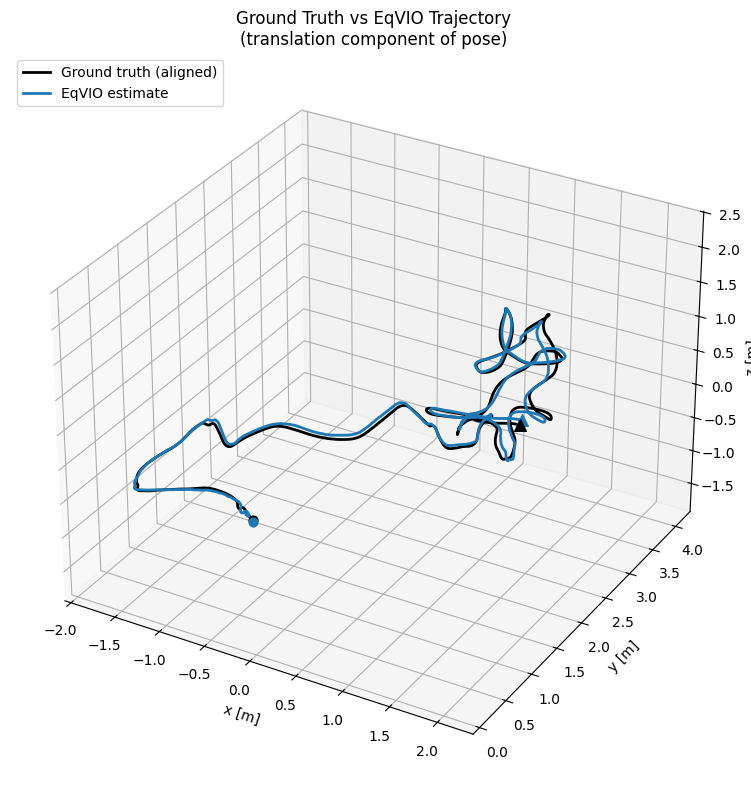

In [ ]:

plot_trajectory_3d(results)



## Plot 2: Velocity Comparison

For velocity, we can compare more directly. The Python wrapper's `velocity()` output matches a **body-frame** convention well, so we rotate the EuRoC world-frame velocity into the body frame using the ground-truth orientation and then plot the components over time.


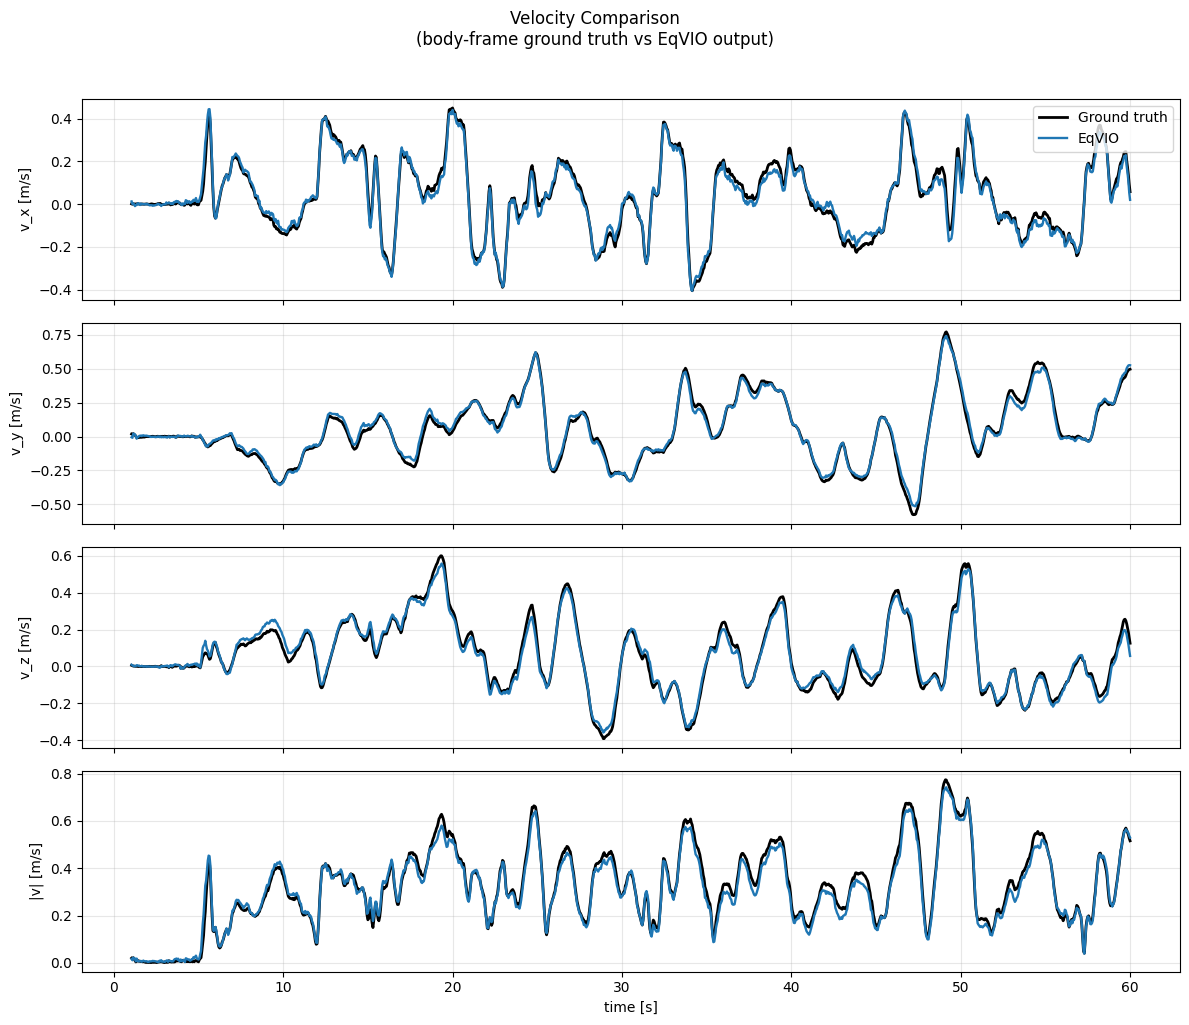

In [ ]:

plot_velocity_comparison(results)



## Takeaways

This replay gives a compact picture of how the visual-inertial EqF behaves in practice:

- IMU data drives continuous propagation.
- Vision features provide discrete corrections.
- Translation trajectories should be compared only after frame alignment.
- Velocity can be compared more directly in the body frame.

A natural next extension would be to expose the full estimated attitude through the Python bindings so that the notebook can add orientation-error plots as well.
